# Module 3 — Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/processed/telco_cleaned.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df['Churn'].value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

In [6]:
df['Churn'].value_counts(normalize = True) * 100

No     73.463013
Yes    26.536987
Name: Churn, dtype: float64

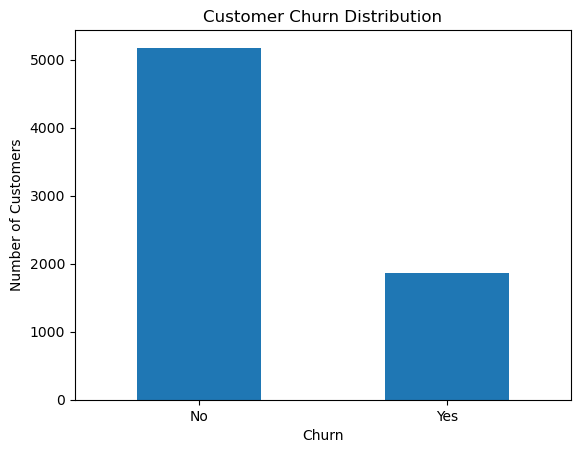

In [7]:
df['Churn'].value_counts().plot(kind = "bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

#### Approximately 26.5% of customers in the dataset have churned, while 73.5% remained. This indicates the dataset is imbalanced, as the majority class ("No") significantly outnumbers the minority class ("Yes"). This imbalance should be considered later when training classification models because some algorithms may become biased toward predicting the majority class.

In [8]:
df['Contract'].value_counts()

Month-to-month    3875
Two year          1695
One year          1473
Name: Contract, dtype: int64

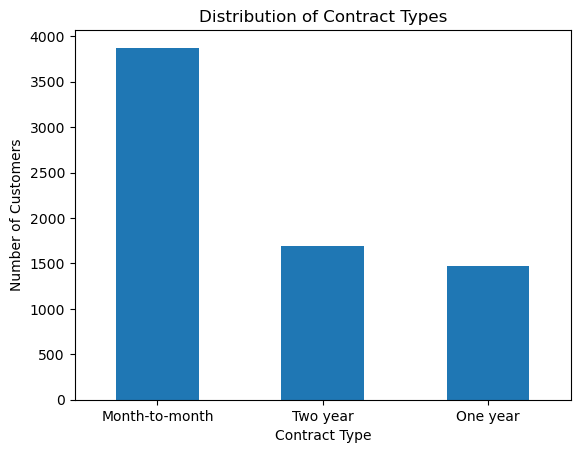

In [9]:
df['Contract'].value_counts().plot(kind = "bar")

plt.title("Distribution of Contract Types")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

#### Month-to-month contracts are the most common among customers, while two-year contracts are the least common.

In [10]:
round(pd.crosstab(df['Contract'], df['Churn'], normalize="index") * 100)

Churn,No,Yes
Contract,,
Month-to-month,57.0,43.0
One year,89.0,11.0
Two year,97.0,3.0


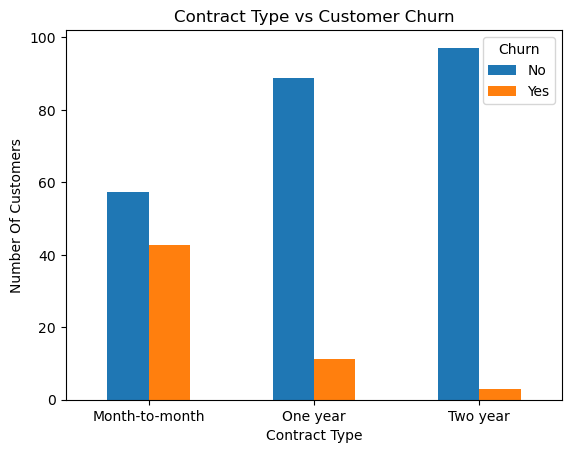

In [11]:
(pd.crosstab(df['Contract'], df['Churn'], normalize="index")*100).plot(kind = "bar")

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number Of Customers")
plt.xticks(rotation = 0)

plt.show()

#### Customers on month-to-month contracts exhibit the highest churn rate, suggesting they have lower commitment and can leave more easily. In contrast, customers with one-year and especially two-year contracts are much more likely to remain with the company. This indicates that contract duration is strongly associated with customer retention and is likely to be an important predictive feature in a churn prediction model.

In [12]:
df['InternetService'].value_counts()

Fiber optic    3096
DSL            2421
No             1526
Name: InternetService, dtype: int64

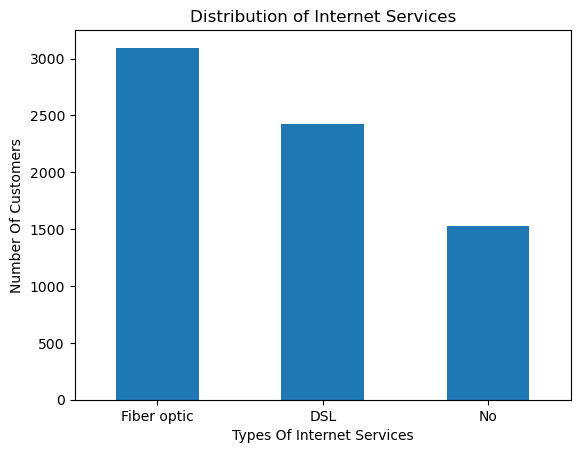

In [13]:
df['InternetService'].value_counts().plot(kind = "bar")

plt.title("Distribution of Internet Services")
plt.xlabel("Types Of Internet Services")
plt.ylabel("Number Of Customers")
plt.xticks(rotation=0)

plt.show()

In [14]:
round(pd.crosstab(df['InternetService'], df['Churn'], normalize="index") * 100)

Churn,No,Yes
InternetService,,
DSL,81.0,19.0
Fiber optic,58.0,42.0
No,93.0,7.0


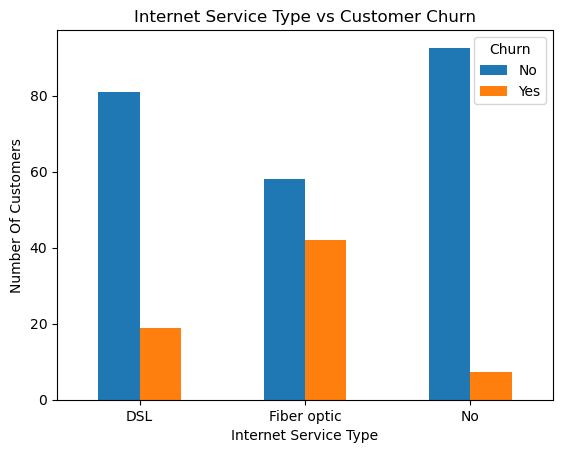

In [15]:
(pd.crosstab(df['InternetService'], df['Churn'], normalize="index") * 100).plot(kind = "bar")
plt.title("Internet Service Type vs Customer Churn")
plt.xlabel("Internet Service Type")
plt.ylabel("Number Of Customers")
plt.xticks(rotation = 0)

plt.show()

#### Customers on Fibric Optic exhibit the highest churn rate, suggesting they have lower commitment and can leave more easily. In contrast, customers with DSL and especially NO Internet Services are much more likely to remain with the company. This indicates that InternetService duration is strongly associated with customer retention and is likely to be an important predictive feature in a churn prediction model.

In [16]:
df['PaymentMethod'].value_counts()

Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: PaymentMethod, dtype: int64

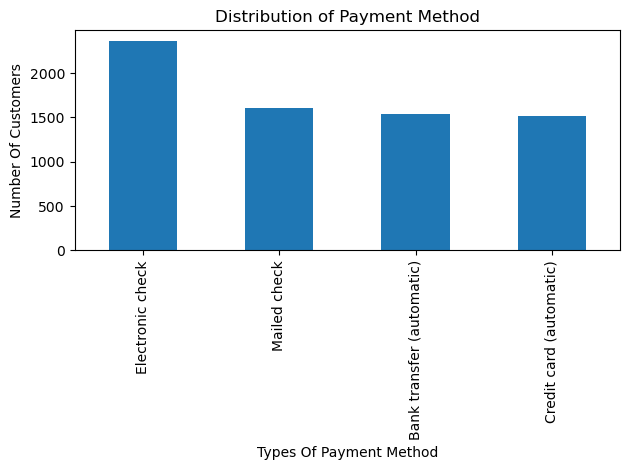

In [17]:
df['PaymentMethod'].value_counts().plot(kind = "bar", )

plt.title("Distribution of Payment Method")
plt.xlabel("Types Of Payment Method")
plt.ylabel("Number Of Customers")
plt.tight_layout()
plt.show()

In [18]:
round(pd.crosstab(df['PaymentMethod'], df['Churn'], normalize="index") * 100)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.0,17.0
Credit card (automatic),85.0,15.0
Electronic check,55.0,45.0
Mailed check,81.0,19.0


<module 'matplotlib.pyplot' from 'C:\\Users\\hp\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

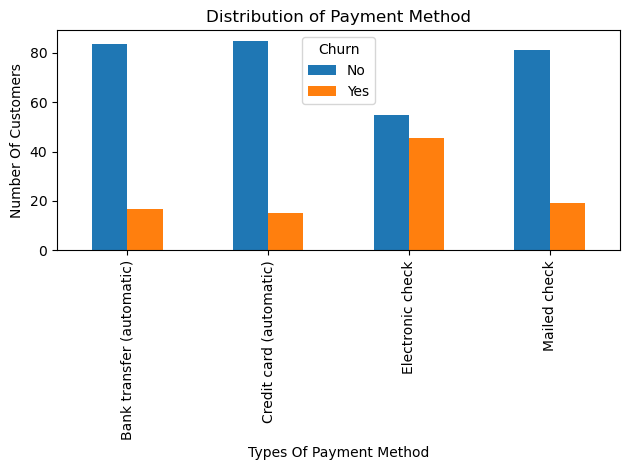

In [19]:
(pd.crosstab(df['PaymentMethod'], df['Churn'], normalize="index")*100).plot(kind = "bar")
plt.title("Distribution of Payment Method")
plt.xlabel("Types Of Payment Method")
plt.ylabel("Number Of Customers")
plt.tight_layout()
plt

#### Customers on electric check payment method exhibit the highest churn rate, suggesting they have lower commitment and can leave more easily. In contrast, customers with Bank Transfer, Credit Card and especially Mailed Check payment method are much more likely to remain with the company. This indicates that InternetService duration is strongly associated with customer retention and is likely to be an important predictive feature in a churn prediction model.

## TENURE VS CHURN

In [20]:
df['tenure'].value_counts()

1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: tenure, Length: 73, dtype: int64

In [21]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

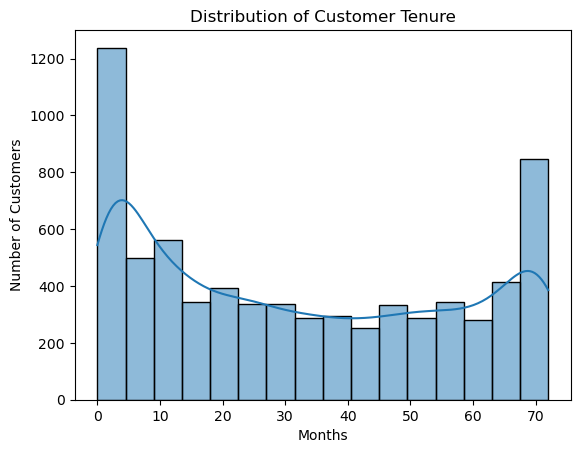

In [22]:
import seaborn as sns

sns.histplot(df['tenure'], kde= True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Months")
plt.ylabel("Number of Customers")

plt.show()

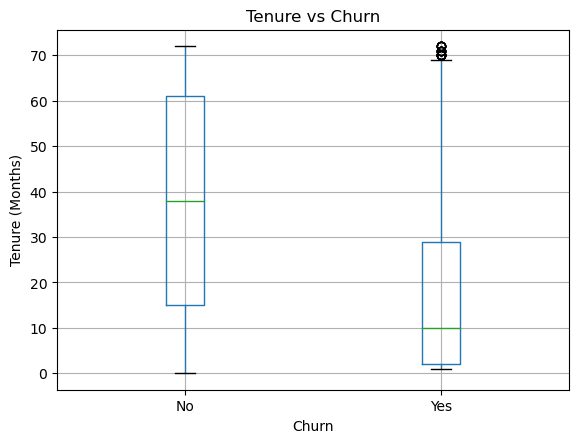

In [23]:
df.boxplot(
    column="tenure",
    by="Churn"
)

plt.title("Tenure vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()
plt.show()

#### Customers who churn generally have significantly shorter tenure than customers who remain with the company. This suggests that newer customers are at a higher risk of leaving, while long-term customers tend to be more loyal. Customer tenure therefore appears to be a strong predictor of churn.m

In [43]:
bine = [0,12,24,48,72]

labels = ["0-1 Years", "1-2 Years","2-4 Years","4-6 Years"]

df["TenureGroup"] = pd.cut(
    df['tenure'],
    bins=bine,
    labels=labels,
    include_lowest=True
)

In [44]:
df['TenureGroup'].value_counts()

4-6 Years    2239
0-1 Years    2186
2-4 Years    1594
1-2 Years    1024
Name: TenureGroup, dtype: int64

In [45]:
pd.crosstab(df['TenureGroup'], df['Churn'], normalize=True)*100

Churn,No,Yes
TenureGroup,,
0-1 Years,16.314071,14.723839
1-2 Years,10.364901,4.174358
2-4 Years,18.017890,4.614511
4-6 Years,28.766151,3.024279


(array([0, 1, 2, 3]),
 [Text(0, 0, '0-1 Years'),
  Text(1, 0, '1-2 Years'),
  Text(2, 0, '2-4 Years'),
  Text(3, 0, '4-6 Years')])

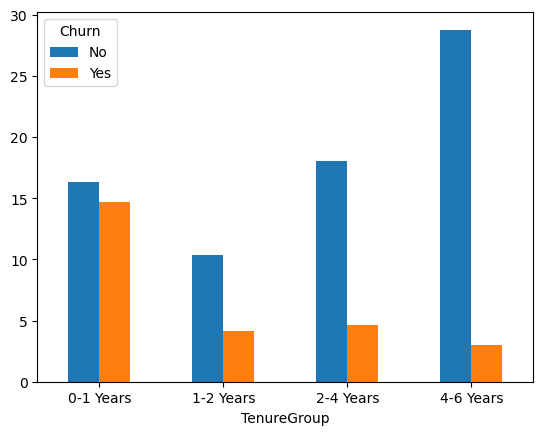

In [27]:
(pd.crosstab(df['TenureGroup'], df['Churn'], normalize=True)*100).plot(kind = "bar")
plt.xticks(rotation = 0)

In [46]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 Years
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4 Years
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 Years
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 Years
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 Years


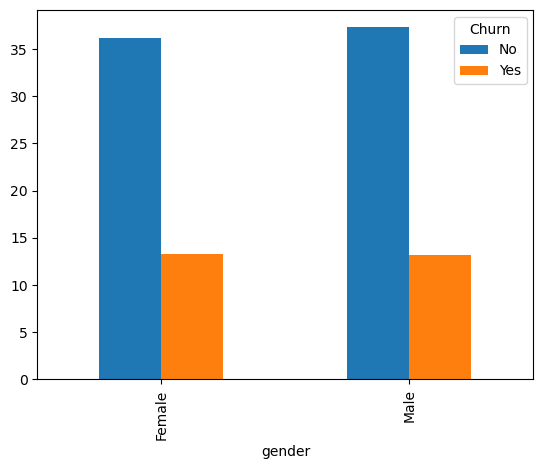

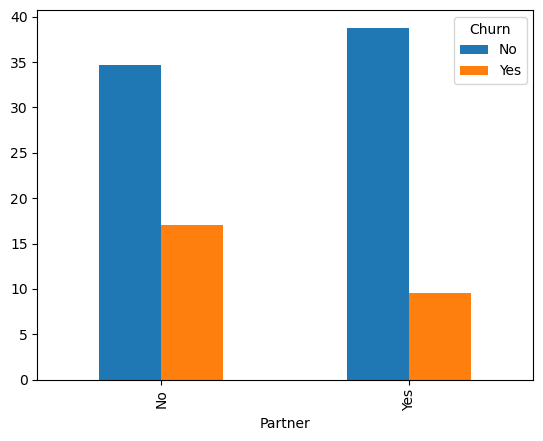

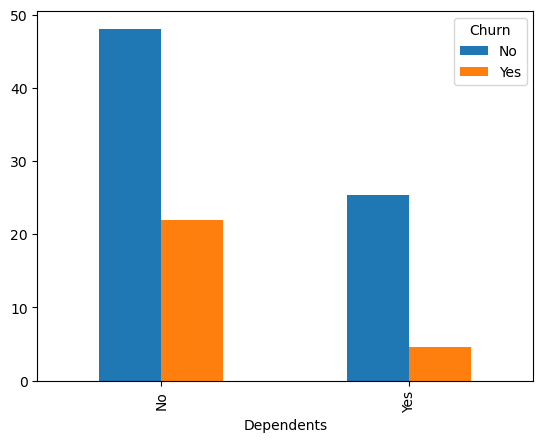

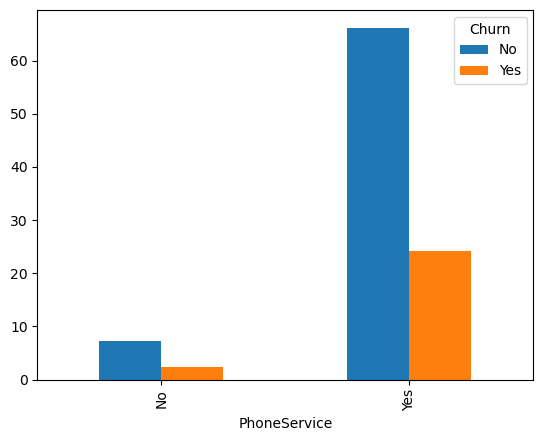

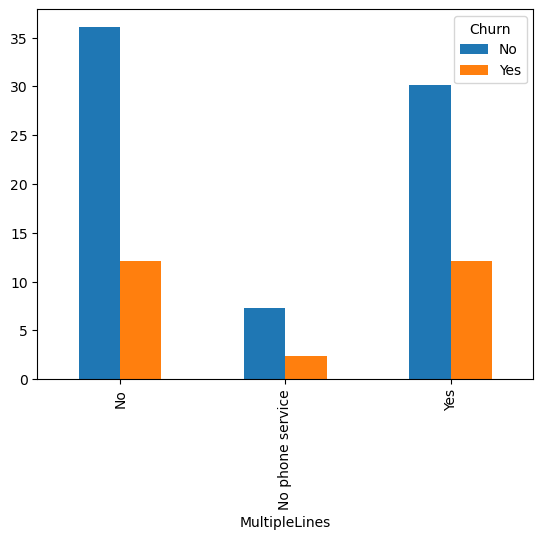

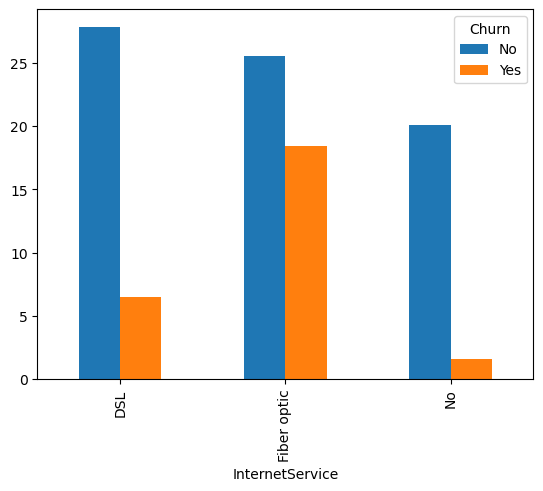

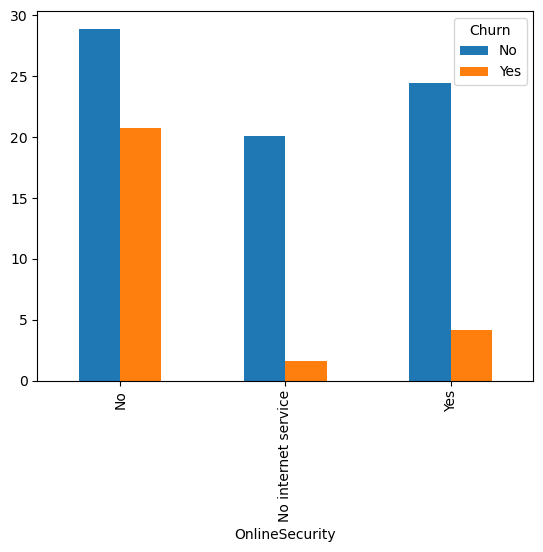

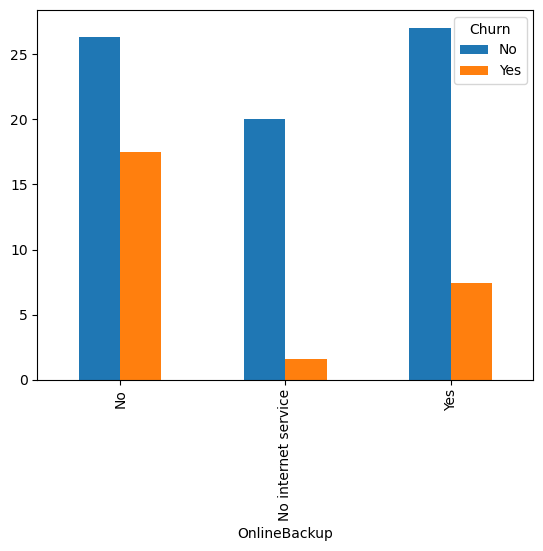

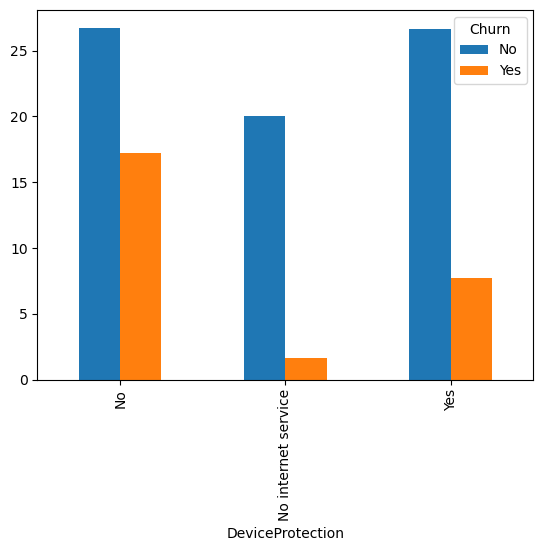

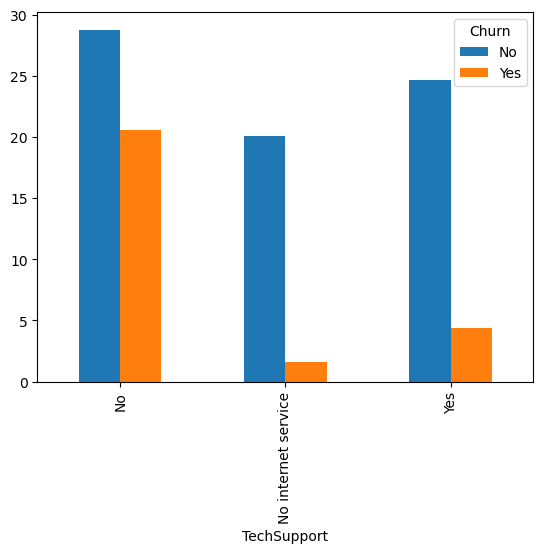

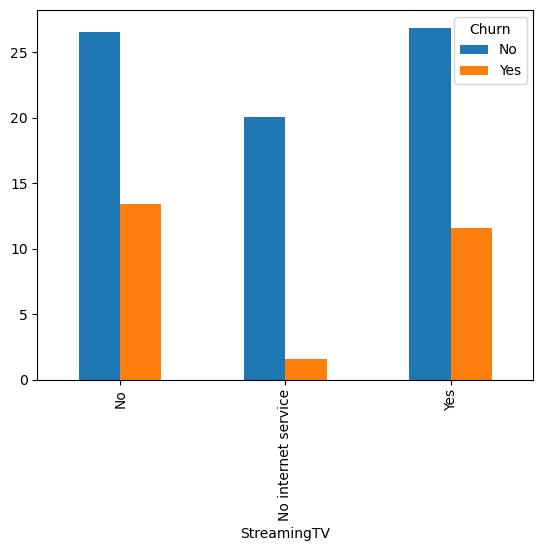

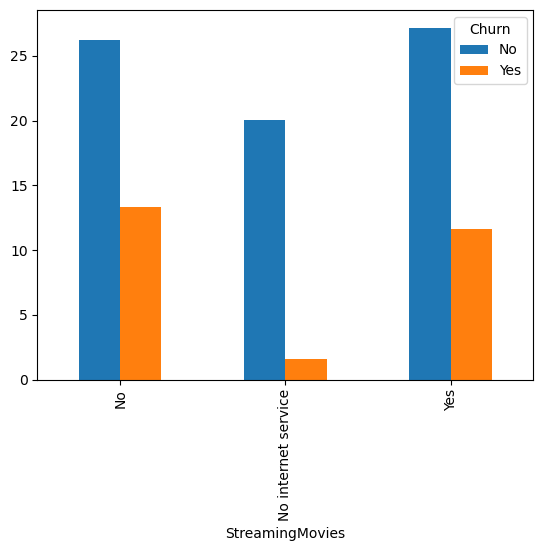

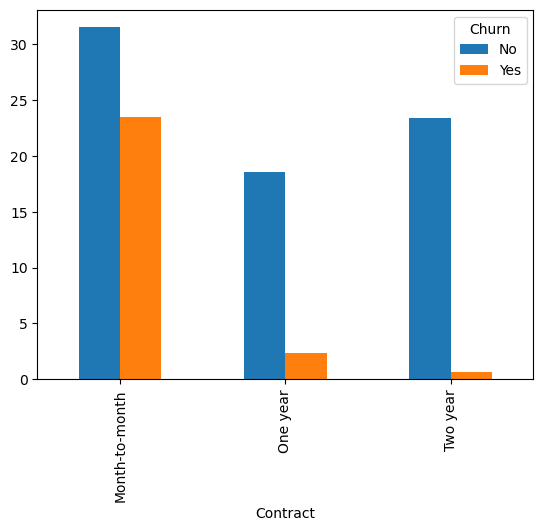

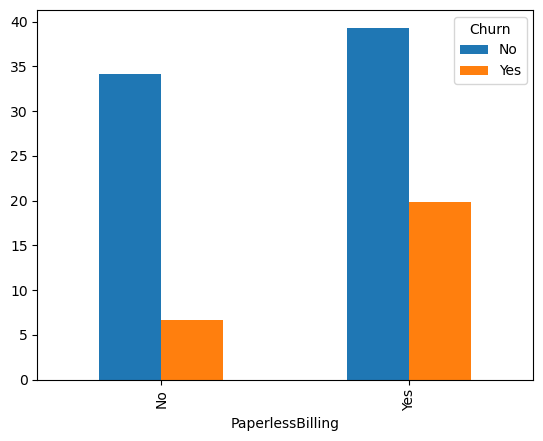

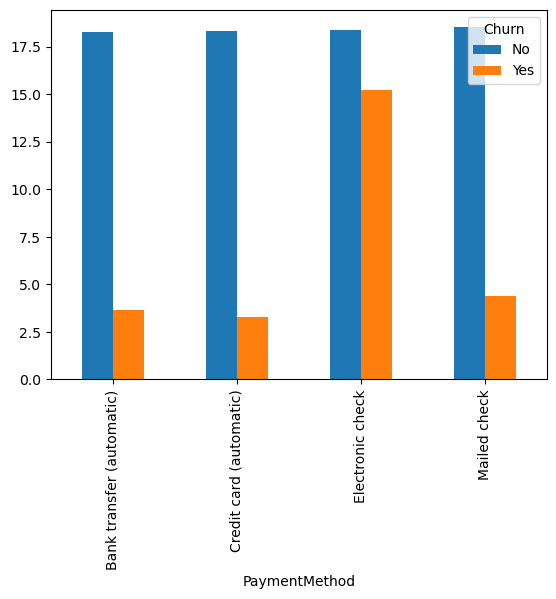

In [47]:
Categorical_col = df.select_dtypes(include="object").columns.drop(['customerID', 'Churn'])

for col in Categorical_col:
    churn_rate = (pd.crosstab(
        df[col],
        df['Churn'],
        normalize = True) * 100).plot(kind = "bar", )

In [48]:
df.to_csv("../data/processed/telco_cleaned.csv")